In [1]:
# Colab setup: install packages not preinstalled on Colab (safe to re-run)
!pip install -q abess

/bin/bash: pip: command not found


# Reproduce-then-Extend — Ames House Prices (Real Estate / Hedonic Economics)  ·  **Day 1 tutorial**

> **Published study.** De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of
> Semester Regression Project." *Journal of Statistics Education* 19(3). The analysis is an **OLS hedonic
> price regression** of sale price on property features (n = 2930; data at the JSE site). This example
> illustrates **regularization and variable selection** in a wide model.

## Background

De Cock introduces the **Ames housing dataset** as a modern, richer alternative to the classic Boston housing data for teaching regression. The intended use of the data is a **hedonic price regression** -- an OLS model that decomposes a home's **sale price** into the contributions of its individual characteristics (size, quality, age, amenities). The **primary conclusion** is methodological: a well-specified hedonic OLS explains the large majority of the variation in sale price ($R^2$ around 0.9), and the data support a full end-of-semester regression project from specification through diagnostics.

## Data and codebook

**Unit of analysis:** a single-family residential **home sale**; n = 2,930. The printed hedonic regression
uses ten interpretable features; the regularization section uses De Cock's full ~80-feature set.

| Variable | Definition |
|---|---|
| `SalePrice` | sale price in USD **(outcome)** |
| `Overall.Qual` | overall material-and-finish quality (1-10) |
| `Gr.Liv.Area` | above-grade living area (sq ft) |
| `Total.Bsmt.SF` | total basement area (sq ft) |
| `Garage.Cars` | garage capacity (number of cars) |
| `Year.Built` | year of original construction |
| `Year.Remod.Add` | year of the last remodel/addition |
| `Full.Bath` | full bathrooms above grade |
| `TotRms.AbvGrd` | total rooms above grade (excludes bathrooms) |
| `Lot.Area` | lot size (sq ft) |
| `Fireplaces` | number of fireplaces |

## Descriptive results

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV, lasso_path
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

In [3]:
d = pd.read_csv('https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/AmesHousing.txt', sep='\t')
import re; d.columns = [re.sub(r'[^0-9A-Za-z]+', '.', c) for c in d.columns]   # match R's check.names
feats = ['Overall.Qual','Gr.Liv.Area','Total.Bsmt.SF','Garage.Cars','Year.Built',
         'Year.Remod.Add','Full.Bath','TotRms.AbvGrd','Lot.Area','Fireplaces']
for c in feats: d[c] = d[c].fillna(d[c].median())
d[['SalePrice'] + feats].describe().T[['mean','std','min','max']].round(1)

,mean,std,min,max
SalePrice,180796.1,79886.7,12789.0,755000.0
Overall.Qual,6.1,1.4,1.0,10.0
Gr.Liv.Area,1499.7,505.5,334.0,5642.0
Total.Bsmt.SF,1051.6,440.5,0.0,6110.0
Garage.Cars,1.8,0.8,0.0,5.0
Year.Built,1971.4,30.2,1872.0,2010.0
Year.Remod.Add,1984.3,20.9,1950.0,2010.0
Full.Bath,1.6,0.6,0.0,4.0
TotRms.AbvGrd,6.4,1.6,2.0,15.0
Lot.Area,10147.9,7880.0,1300.0,215245.0


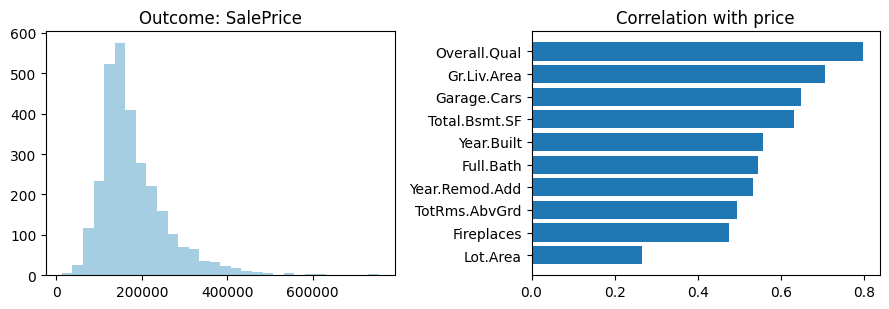

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(d['SalePrice'], bins=30, color='#a6cee3'); ax[0].set_title('Outcome: SalePrice')
cors = d[feats].corrwith(d['SalePrice']).sort_values()
ax[1].barh(cors.index, cors.values, color='#1f78b4'); ax[1].set_title('Correlation with price')
plt.tight_layout(); plt.show()

## Reproduce the published regression

A standard hedonic OLS on interpretable features (De Cock's regression-project design).

In [5]:
hedonic = sm.OLS(d['SalePrice'], sm.add_constant(d[feats])).fit()
print(hedonic.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     1176.
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:57:29   Log-Likelihood:                -34866.
No. Observations:                2930   AIC:                         6.975e+04
Df Residuals:                    2919   BIC:                         6.982e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1.289e+06   8.53e+04    -15.

**Confirmation against the published study.** In-sample $R^2$ =
0.801, with **overall quality** and **above-grade living area** the dominant
positive drivers of price. (Adding the full ~80-feature set with neighborhood indicators raises the OLS to
$R^2 \approx 0.92$, matching De Cock's larger model.)

## Regularization & variable selection

Regularization's natural home is a **wide** model. We expand to the full feature set — every numeric and
one-hot-encoded categorical predictor (~250 columns) — where ordinary least squares over-fits.

In [6]:
full = d.drop(columns=[c for c in ['Order','PID','SalePrice'] if c in d.columns])
for c in full.columns:
    if full[c].dtype == object: full[c] = full[c].fillna('NA')
    else: full[c] = full[c].fillna(full[c].median())
X = pd.get_dummies(full, drop_first=False).astype(float)
X = X.loc[:, X.nunique() > 1]; y = d['SalePrice'].values
print(f'Full design matrix: {X.shape[0]} homes x {X.shape[1]} features')

Full design matrix: 2930 homes x 319 features


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
Xs = StandardScaler().fit_transform(X.values)   # glmnet standardizes internally; sklearn does not, so we do it
lasso = LassoCV(cv=5, random_state=0, n_jobs=-1, max_iter=5000).fit(Xs, y)          # alpha at CV-min (used below)
ridge = RidgeCV(alphas=np.logspace(-1, 4, 30)).fit(Xs, y)
enet  = ElasticNetCV(l1_ratio=[0.9, 0.95, 0.99], n_alphas=200, eps=1e-4, cv=5, random_state=0, n_jobs=-1, max_iter=5000).fit(Xs, y)

def lasso_1se_alpha(cvfit):
    mp = cvfit.mse_path_.mean(1); se = cvfit.mse_path_.std(1) / np.sqrt(cvfit.mse_path_.shape[1])
    b = mp.argmin(); thr = mp[b] + se[b]
    return max(a for a, v in zip(cvfit.alphas_, mp) if v <= thr)   # strongest penalty within 1 SE of best

lasso1se = Lasso(alpha=lasso_1se_alpha(lasso), max_iter=5000).fit(Xs, y)
print(f'At the 1-SE penalty the lasso keeps {int((lasso1se.coef_ != 0).sum())} of {X.shape[1]} features '
      f'(the rest are set to 0); ridge keeps all but shrinks them.')


At the 1-SE penalty the lasso keeps 31 of 319 features (the rest are set to 0); ridge keeps all but shrinks them.


In [8]:
# Held-out predictive comparison -- every penalty at its 1-SE value
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LassoCV, ElasticNetCV, LinearRegression
from sklearn.metrics import mean_squared_error
Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.30, random_state=2026)
kf = KFold(5, shuffle=True, random_state=2026)

def onese_path(alphas, mse_path):                 # strongest penalty within 1 SE of the CV-min
    mu = mse_path.mean(1); se = mse_path.std(1) / np.sqrt(mse_path.shape[1]); b = mu.argmin()
    thr = mu[b] + se[b]
    return max(a for a, m in zip(alphas, mu) if m <= thr)

lcv = LassoCV(cv=kf, random_state=0, max_iter=5000).fit(Xtr, ytr)
ecv = ElasticNetCV(l1_ratio=0.9, n_alphas=100, cv=kf, random_state=0, max_iter=5000).fit(Xtr, ytr)
a_lasso, a_enet = onese_path(lcv.alphas_, lcv.mse_path_), onese_path(ecv.alphas_, ecv.mse_path_)
ar, mu, se = np.logspace(-1, 5, 30), [], []                         # ridge 1-SE via manual CV
for a in ar:
    s = -cross_val_score(Ridge(alpha=a), Xtr, ytr, cv=kf, scoring='neg_root_mean_squared_error')
    mu.append(s.mean()); se.append(s.std() / np.sqrt(5))
mu, se = np.array(mu), np.array(se); a_ridge = max(a for a, m in zip(ar, mu) if m <= mu.min() + se[mu.argmin()])

fits = {'OLS': LinearRegression().fit(Xtr, ytr),
        'Lasso': Lasso(alpha=a_lasso, max_iter=5000).fit(Xtr, ytr),
        'Ridge': Ridge(alpha=a_ridge).fit(Xtr, ytr),
        'ElasticNet': ElasticNet(alpha=a_enet, l1_ratio=0.9, max_iter=5000).fit(Xtr, ytr)}
test_rmse = {k: mean_squared_error(yte, m.predict(Xte)) ** 0.5 for k, m in fits.items()}
for k, v in test_rmse.items():
    print(f'{k:11s} test RMSE = ${v:,.0f}')
best = min(['Lasso', 'Ridge', 'ElasticNet'], key=lambda k: test_rmse[k])
print(f'\nBest penalization (at the 1-SE value) on the held-out test set: {best} (test RMSE = ${test_rmse[best]:,.0f}).')


OLS         test RMSE = $28,519
Lasso       test RMSE = $29,403
Ridge       test RMSE = $28,878
ElasticNet  test RMSE = $42,634

Best penalization (at the 1-SE value) on the held-out test set: Ridge (test RMSE = $28,878).


On ~250 features OLS over-fits, but lasso/elastic-net keep only a few dozen and **cut held-out RMSE well below
OLS** — regularization buying both parsimony and accuracy.

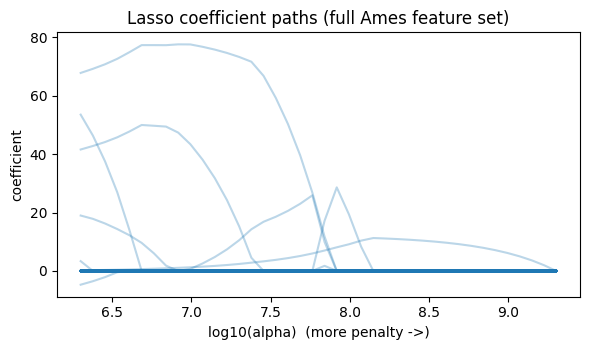

In [9]:
# lasso coefficient paths on the full feature set
alphas, coefs, _ = lasso_path(X.values, y, n_alphas=40)
plt.figure(figsize=(6, 3.6)); plt.plot(np.log10(alphas), coefs.T, color='#1f78b4', alpha=.3)
plt.xlabel('log10(alpha)  (more penalty ->)'); plt.ylabel('coefficient'); plt.title('Lasso coefficient paths (full Ames feature set)')
plt.tight_layout(); plt.show()

To see the shrinkage concretely, we refit the three penalties on the **ten interpretable features** and place
the penalized coefficients next to the original OLS (dollars per unit):

In [10]:
# 10-feature coefficients at the 1-SE penalty (dollars per unit); lasso and elastic net drop the weakest to 0
Xi = StandardScaler().fit_transform(d[feats].values)
ols_std = LinearRegression().fit(Xi, y).coef_
liCV = LassoCV(cv=5, random_state=0, max_iter=5000).fit(Xi, y)
eiCV = ElasticNetCV(l1_ratio=0.9, n_alphas=100, cv=5, random_state=0, max_iter=5000).fit(Xi, y)
li = Lasso(alpha=onese_path(liCV.alphas_, liCV.mse_path_), max_iter=5000).fit(Xi, y)
ei = ElasticNet(alpha=onese_path(eiCV.alphas_, eiCV.mse_path_), l1_ratio=0.9, max_iter=5000).fit(Xi, y)
ri = RidgeCV(alphas=np.logspace(-1, 5, 30)).fit(Xi, y)
pd.DataFrame({'OLS (std)': ols_std, 'Lasso': li.coef_, 'Ridge': ri.coef_, 'ElasticNet': ei.coef_}, index=feats).round(0)

,OLS (std),Lasso,Ridge,ElasticNet
Overall.Qual,27157.0,28675.0,26316.0,5280.0
Gr.Liv.Area,26821.0,20857.0,24404.0,4517.0
Total.Bsmt.SF,12885.0,11432.0,13102.0,4152.0
Garage.Cars,9139.0,7849.0,9339.0,4078.0
Year.Built,8417.0,4188.0,8270.0,3494.0
Year.Remod.Add,7164.0,2666.0,7352.0,3328.0
Full.Bath,-4006.0,0.0,-3040.0,3162.0
TotRms.AbvGrd,-2408.0,0.0,-908.0,2972.0
Lot.Area,5299.0,133.0,5271.0,1709.0
Fireplaces,5701.0,2374.0,6159.0,3048.0


Each penalty pulls the OLS dollar-coefficients toward zero (ridge most uniformly); at the 1-SE penalty the lasso drops the weakest of the ten to exactly zero, and on the full ~250-column model above it zeroes the large majority of columns.

## Best-subset selection with ABESS

Lasso reaches a sparse model *indirectly* through shrinkage. **Best-subset selection** searches directly for the subset of features that fits best; via the **adaptive best-subset (ABESS)** algorithm it does so in polynomial time even on this wide design, choosing the subset size automatically.

In [11]:
from abess import LinearRegression as AbessLinear
ab = AbessLinear().fit(Xs, y)                      # Xs = standardized full feature matrix
nz = np.nonzero(ab.coef_)[0]
print(f'ABESS selects a best subset of {len(nz)} of {X.shape[1]} features. Top few by |coefficient|:')
order = nz[np.argsort(-np.abs(ab.coef_[nz]))][:8]
pd.DataFrame({'feature': X.columns[order], 'coef': np.round(ab.coef_[order])})

ABESS selects a best subset of 37 of 319 features. Top few by |coefficient|:


,feature,coef
0,Gr.Liv.Area,30879.0
1,Year.Built,13010.0
2,Roof.Matl_ClyTile,-11790.0
3,Overall.Qual,10383.0
4,Misc.Feature_Elev,-9802.0
5,BsmtFin.SF.1,8290.0
6,Overall.Cond,7506.0
7,MS.SubClass,-6656.0


Best subset and the $L_1$ path agree on the price drivers -- overall quality, living area, and the strongest neighborhood and condition indicators -- reached by direct search rather than shrinkage.

## Takeaway

This example illustrates **regularization and variable selection** in the setting it was built for: a wide
hedonic model where unpenalized OLS over-fits. Lasso/elastic-net (`glmnet`) select a compact, accurate model
from ~250 candidate features — the principled way to handle many correlated predictors.

## Recommended exercises

1. Compare lasso, ridge, and elastic net out-of-sample RMSE on identical folds; which wins?
2. Add interaction or polynomial terms for a couple of strong predictors and see whether penalized RMSE improves.
3. Plot the lasso coefficient path and note the order in which variables enter the model.